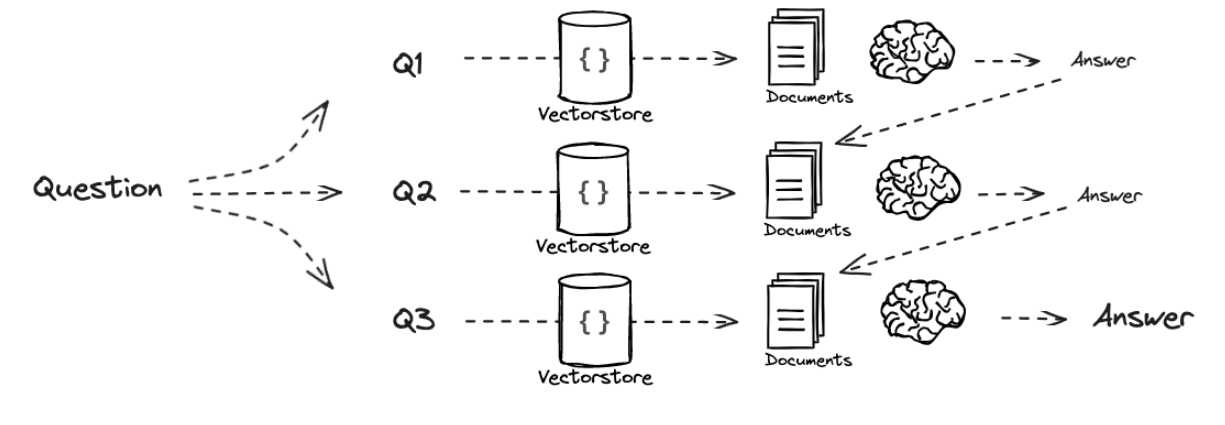

In [2]:
import bs4
import os
from langchain_community.document_loaders import WebBaseLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("ADV_RAG_KEY")

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
blog_docs

USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [3]:
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300, 
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)
splits, "", len(splits)

([Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and ref

In [4]:
vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001"))

retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 4, "fetch_k": 20, "lambda_mult": 0.5}
)
retriever 

VectorStoreRetriever(tags=['Chroma', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001287154DB90>, search_type='mmr', search_kwargs={'k': 4, 'fetch_k': 20, 'lambda_mult': 0.5})

In [5]:
retriever.invoke("What is task decomposition?")

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import (
    RunnableLambda,
    RunnableParallel,
    RunnablePassthrough,
)
from langchain_google_genai import ChatGoogleGenerativeAI


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, api_key=api_key)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x000001284B035E90>, default_metadata=(), model_kwargs={})

In [7]:
decomposition_prompt = ChatPromptTemplate.from_template("""
Break the following question into 3 sub-questions that can be answered in isolation.

Question:
{question}

Return only the questions separated by newlines.
""")

generate_subquestions = (
    decomposition_prompt
    | llm
    | StrOutputParser()
    | RunnableLambda(
        lambda x: x.split("\n")
    )
)

In [8]:
question = "What are the main components of an LLM-powered autonomous agent system?"
questions = generate_subquestions.invoke({"question":question})
questions

["What is the central role and function of the Large Language Model (LLM) within the agent's architecture?",
 'How does the agent perceive its environment and execute actions through external tools or interfaces?',
 'What internal mechanisms does the agent use for memory, planning, and self-reflection?']

In [9]:
recursive_prompt = ChatPromptTemplate.from_template("""
You must answer this question:

Question:
{question}

Previous Q&A pairs:
{q_a_pairs}

Retrieved Context:
{context}

Answer the question carefully using the above context.
""")

In [12]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

def format_qa_pair(question, answer):
    return (f"Question: {question} \n Answer: {answer}")

In [13]:
q_a_pairs = ""

for sub_question in questions:

    docs = retriever.invoke(sub_question)

    context = format_docs(docs)

    rag_chain = (
        recursive_prompt
        | llm
        | StrOutputParser()
    )

    answer = rag_chain.invoke({
        "question": sub_question,
        "context": context,
        "q_a_pairs": q_a_pairs,
    })

    q_a_pairs += ("\n\n---\n\n"+ format_qa_pair(sub_question, answer))

In [15]:
print(q_a_pairs)



---

Question: What is the central role and function of the Large Language Model (LLM) within the agent's architecture? 
 Answer: The Large Language Model (LLM) plays several central and critical roles within the agent's architecture:

1.  **Router and Model Selector:** The LLM acts as a general-purpose router, distributing tasks to specialized "expert" models. It is responsible for selecting the most suitable expert model from a list based on the user's request and the task type, often framing this as a multiple-choice question. This function is explicitly highlighted by the MRKL architecture, where the LLM routes inquiries to the best suitable expert module.
2.  **Reflection and Memory Synthesis:** The LLM is integral to the reflection mechanism. It synthesizes raw observations and memories into higher-level inferences over time. This involves being prompted with recent observations to generate salient high-level questions and then answering those questions to create summaries of p

In [16]:
final_synthesis_prompt = ChatPromptTemplate.from_template("""
You are given a set of question-answer pairs
generated while solving a larger problem.

Q&A Pairs:
{q_a_pairs}

Using the above information,
answer the original question:

{question}
""")

final_synthesis_chain = (
    final_synthesis_prompt
    | llm
    | StrOutputParser()
)

final_answer = final_synthesis_chain.invoke({
    "question": question,
    "q_a_pairs": q_a_pairs,
})

print(final_answer)

Based on the provided Q&A pairs, the main components of an LLM-powered autonomous agent system can be identified as follows:

1.  **Large Language Model (LLM) Core:**
    *   **Central Orchestrator:** Acts as a general-purpose router and model selector, distributing tasks to specialized "expert" models.
    *   **Cognitive Engine:** Integral to reflection, memory synthesis, planning, and action generation.
    *   **Communication Hub:** Responsible for natural language processing and generation, including inter-agent communication and presenting analysis results to the user.
    *   **Tool Interface Manager:** Crucial for understanding when and how to use external tools and APIs, including extracting necessary arguments.

2.  **Memory System:**
    *   **Multi-faceted Storage:** Employs different types of memory, including Sensory Memory (brief impressions) and Short-Term/Working Memory (currently processed information, where reflections are added).
    *   **Observation Storage:** Sto